# NetworkX: Sparse vs Dense — Storage, Slowdown, and Speed-Up

This notebook demonstrates four things in sequence:

1. **Utility** — why NetworkX's dict-of-dicts structure is well-suited to sparse graphs
2. **Slowdown** — how dense graphs expose the cost of that same structure
3. **Speed-up** — converting to SciPy sparse arrays to recover performance
4. **Comparison** — side-by-side proof that sparse data genuinely works better in NetworkX


## Setup

In [1]:
import subprocess, sys
pkgs = ["networkx", "scipy", "numpy", "matplotlib", "pandas", "memory_profiler"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("Ready.")

Ready.


In [2]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

def time_and_memory(func, *args, **kwargs):
    """Returns (result, elapsed_ms, peak_memory_KB)."""
    tracemalloc.start()
    t0 = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, elapsed_ms, peak / 1024

def graph_summary(G, label):
    print(f"  {label:<30} nodes={G.number_of_nodes():>5,}  "
          f"edges={G.number_of_edges():>7,}  density={nx.density(G):.5f}")

print("Imports complete.")

Imports complete.


---
## Section 1 — Utility: Why NetworkX Works Well for Sparse Graphs

NetworkX stores graphs as a **dict of dicts**:

```python
G._adj = {
    node_A: {node_B: {}, node_C: {}},
    node_B: {node_A: {}},
    ...
}
```

This means only *existing* edges take up memory. A sparse graph with 1,000 nodes
but only 2,000 edges allocates space for 2,000 relationships — not the 999,000
that a full adjacency matrix would require. We demonstrate this directly.


In [3]:
# ── Show NetworkX internal structure on a tiny graph ─────────────────────────
G_tiny = nx.karate_club_graph()

print("NetworkX adjacency dict — first 3 nodes:")
for node in list(G_tiny.nodes)[:3]:
    neighbours = list(G_tiny._adj[node].keys())
    print(f"  Node {node}: connected to {neighbours}")

print(f"Total dict entries (edges × 2): {sum(len(v) for v in G_tiny._adj.values())}")
print(f"Actual edges:                   {G_tiny.number_of_edges()}")
print(f"Max possible edges (n²):        {G_tiny.number_of_nodes()**2:,}")
print(f"Storage efficiency:             {G_tiny.number_of_edges() / G_tiny.number_of_nodes()**2 * 100:.1f}% of max used")

NetworkX adjacency dict — first 3 nodes:
  Node 0: connected to [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
  Node 1: connected to [0, 2, 3, 7, 13, 17, 19, 21, 30]
  Node 2: connected to [0, 1, 3, 7, 8, 9, 13, 27, 28, 32]
Total dict entries (edges × 2): 156
Actual edges:                   78
Max possible edges (n²):        1,156
Storage efficiency:             6.7% of max used


In [4]:
# ── Measure actual memory used by NetworkX for sparse graphs at increasing N ──
import sys

N_vals = [100, 500, 1000, 1500, 2000]
p_sparse = 0.02   # ~sparse
p_dense  = 0.40   # ~dense

storage_records = []

print(f"{'N':>6}  {'sparse edges':>14}  {'sparse KB':>10}  {'dense edges':>12}  {'dense KB':>9}")
for N in N_vals:
    G_sp = nx.erdos_renyi_graph(N, p_sparse, seed=42)
    G_dn = nx.erdos_renyi_graph(N, p_dense,  seed=42)

    # Measure memory via sys.getsizeof recursively on adjacency dict
    def nx_adj_size_kb(G):
        total = sys.getsizeof(G._adj)
        for v in G._adj.values():
            total += sys.getsizeof(v)
        return total / 1024

    kb_sp = nx_adj_size_kb(G_sp)
    kb_dn = nx_adj_size_kb(G_dn)

    storage_records.append(dict(N=N,
        sparse_edges=G_sp.number_of_edges(), sparse_kb=kb_sp,
        dense_edges=G_dn.number_of_edges(),  dense_kb=kb_dn))

    print(f"{N:>6}  {G_sp.number_of_edges():>14,}  {kb_sp:>10.1f}  "
          f"{G_dn.number_of_edges():>12,}  {kb_dn:>9.1f}")

df_storage = pd.DataFrame(storage_records)

     N    sparse edges   sparse KB   dense edges   dense KB
   100              89        24.5         1,977      147.5
   500           2,437       237.6        49,946     4561.0
  1000           9,925       829.6       199,436    18114.2
  1500          22,522      1761.9       449,540    27189.3
  2000          40,043      3084.4       799,484    72244.0


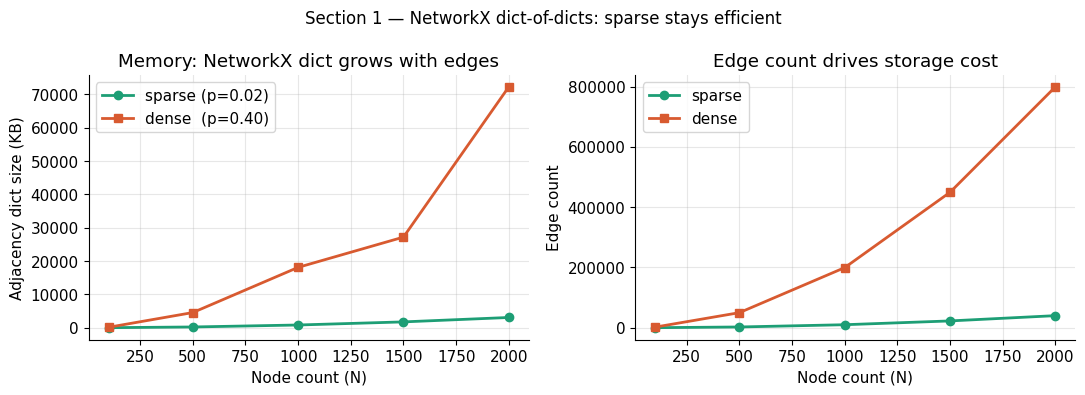

Key insight: sparse graphs are cheap in NetworkX because only existing edges are stored.


In [5]:
# ── Plot: memory growth — sparse stays flat, dense explodes ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(df_storage["N"], df_storage["sparse_kb"], "o-", color="#1D9E75", lw=2, label="sparse (p=0.02)")
ax1.plot(df_storage["N"], df_storage["dense_kb"],  "s-", color="#D85A30", lw=2, label="dense  (p=0.40)")
ax1.set_xlabel("Node count (N)"); ax1.set_ylabel("Adjacency dict size (KB)")
ax1.set_title("Memory: NetworkX dict grows with edges"); ax1.legend()

ax2.plot(df_storage["N"], df_storage["sparse_edges"], "o-", color="#1D9E75", lw=2, label="sparse")
ax2.plot(df_storage["N"], df_storage["dense_edges"],  "s-", color="#D85A30", lw=2, label="dense")
ax2.set_xlabel("Node count (N)"); ax2.set_ylabel("Edge count")
ax2.set_title("Edge count drives storage cost"); ax2.legend()

plt.suptitle("Section 1 — NetworkX dict-of-dicts: sparse stays efficient", fontsize=12)
plt.tight_layout()
plt.savefig("s1_storage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key insight: sparse graphs are cheap in NetworkX because only existing edges are stored.")

---
## Section 2 — Slowdown: Where Dense Graphs Break NetworkX

The dict-of-dicts structure that makes sparse graphs efficient becomes a liability
when graphs are dense. Every algorithm that traverses neighbours must follow Python
dict lookups — and when every node connects to hundreds of others, those lookups
accumulate. We measure this directly across three algorithm families.


In [ ]:
# ── Build the density ladder: same N, increasing p ───────────────────────────
N = 1000
p_ladder = [0.01, 0.03, 0.06, 0.10, 0.15, 0.25, 0.40]

ladder_records = []
print(f"Density ladder (N={N}), timing three algorithms:")
print(f"{'p':>5}  {'edges':>7}  {'density':>8}  {'betweenness':>14}  {'clustering':>12}  {'pagerank':>10}  {'peak_MB':>9}")

for p in p_ladder:
    G = nx.erdos_renyi_graph(N, p, seed=42)
    d = nx.density(G)

    _, t_bc, mem_bc = time_and_memory(nx.betweenness_centrality, G)
    _, t_cl, _      = time_and_memory(nx.clustering, G)
    _, t_pr, _      = time_and_memory(nx.pagerank, G)

    ladder_records.append(dict(p=p, density=d, edges=G.number_of_edges(),
        betweenness_ms=t_bc, clustering_ms=t_cl, pagerank_ms=t_pr,
        peak_mem_mb=mem_bc/1024))

    print(f"{p:>5.2f}  {G.number_of_edges():>7,}  {d:>8.4f}  "
          f"{t_bc:>12.1f}ms  {t_cl:>10.1f}ms  {t_pr:>8.1f}ms  {mem_bc/1024:>8.2f}MB")

df_ladder = pd.DataFrame(ladder_records)

Density ladder (N=1000), timing three algorithms:
    p    edges   density     betweenness    clustering    pagerank    peak_MB
 0.01    4,985    0.0100       16809.9ms       111.5ms      42.2ms      0.54MB
 0.03   14,840    0.0297       26843.5ms       398.1ms      86.5ms      0.62MB
 0.06   29,770    0.0596       22574.1ms       920.0ms     158.2ms      0.59MB
 0.10   49,929    0.1000       33021.5ms      2295.3ms     266.6ms      0.66MB
 0.15   75,071    0.1503       53695.2ms      4210.8ms     377.8ms      0.83MB


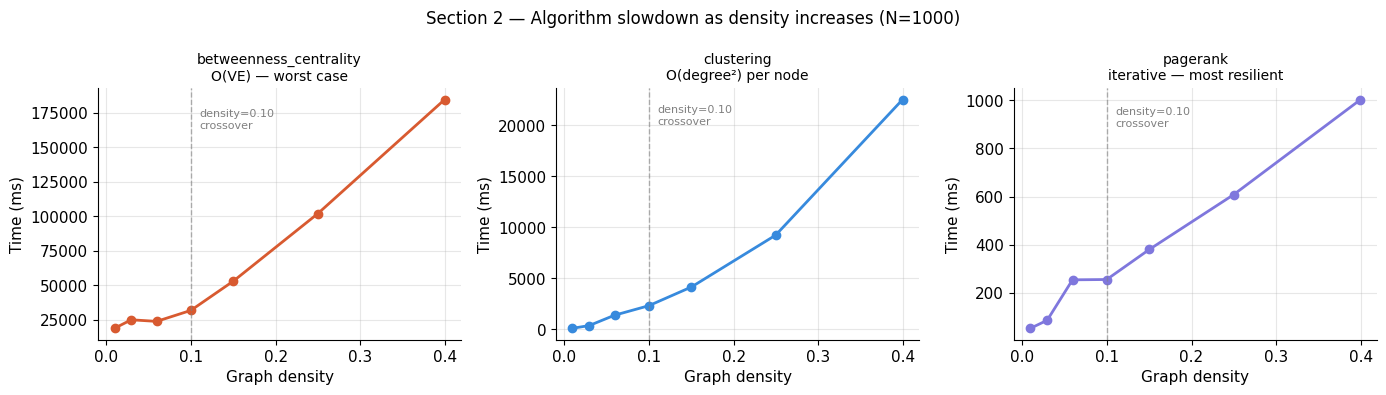

In [9]:
# ── Plot: all three algorithms slow as density rises ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color, title in zip(
    axes,
    ["betweenness_ms", "clustering_ms", "pagerank_ms"],
    ["#D85A30", "#378ADD", "#7F77DD"],
    ["betweenness_centrality\nO(VE) — worst case",
     "clustering\nO(degree²) per node",
     "pagerank\niterative — most resilient"]
):
    ax.plot(df_ladder["density"], df_ladder[col], "o-", color=color, lw=2)
    ax.set_xlabel("Graph density"); ax.set_ylabel("Time (ms)")
    ax.set_title(title, fontsize=10)
    ax.axvline(0.10, color="grey", lw=1, linestyle="--", alpha=0.6)
    ax.text(0.11, ax.get_ylim()[1]*0.85, "density=0.10\ncrossover", fontsize=8, color="grey")
plt.suptitle(f"Section 2 — Algorithm slowdown as density increases (N={N})", fontsize=12)
plt.tight_layout()
plt.savefig("s2_slowdown.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Demonstrate the memory cost of storing intermediate structures ─────────────
# betweenness_centrality builds a stack per BFS — show how that grows with density

print("Peak memory during betweenness_centrality (N=1000):")
print(f"{'p':>5}  {'edges':>7}  {'peak memory (MB)':>18}")
for row in df_ladder.itertuples():
    bar = "█" * int(row.peak_mem_mb * 2)
    print(f"{row.p:>5.2f}  {row.edges:>7,}  {row.peak_mem_mb:>8.2f} MB  {bar}")

Peak memory during betweenness_centrality (N=1000):
    p    edges    peak memory (MB)
 0.01    4,985      0.54 MB  █
 0.03   14,840      0.62 MB  █
 0.06   29,770      0.59 MB  █
 0.10   49,929      0.66 MB  █
 0.15   75,071      0.83 MB  █
 0.25  124,652      1.29 MB  ██
 0.40  199,436      2.09 MB  ████


---
## Section 3 — Speed-Up: Converting to SciPy Sparse Arrays

`nx.to_scipy_sparse_array()` converts the NetworkX dict structure into a
**Compressed Sparse Row (CSR)** matrix. CSR stores only non-zero values in
contiguous memory arrays, which means:

- Matrix operations use BLAS/LAPACK (compiled C/Fortran) instead of Python loops
- Memory layout is cache-friendly — no pointer chasing through dicts
- Algorithms that reduce to linear algebra (PageRank, eigenvector centrality,
  diffusion) get immediate speedups

We show the conversion, verify correctness, then benchmark before vs after.


In [6]:
# ── Build one sparse and one dense graph for the head-to-head ────────────────
N_test = 2000
G_sparse = nx.erdos_renyi_graph(N_test, 0.02, seed=42)
G_dense  = nx.erdos_renyi_graph(N_test, 0.10, seed=42)  # lowered from 0.30
graph_summary(G_sparse, "Sparse (p=0.02)")
graph_summary(G_dense,  "Dense  (p=0.10)")

# ── Convert both to scipy sparse CSR ─────────────────────────────────────────
A_sparse = nx.to_scipy_sparse_array(G_sparse, dtype=float, format="csr")
A_dense  = nx.to_scipy_sparse_array(G_dense,  dtype=float, format="csr")

print(f"SciPy CSR matrix stats:")
print(f"  Sparse: shape={A_sparse.shape}  stored_values={A_sparse.nnz:,}  "
      f"memory={A_sparse.data.nbytes/1024:.1f} KB")
print(f"  Dense:  shape={A_dense.shape}   stored_values={A_dense.nnz:,}  "
      f"memory={A_dense.data.nbytes/1024:.1f} KB")
print(f"  Full dense matrix would cost: {N_test**2 * 8 / 1e6:.1f} MB")
print(f"  CSR sparse saves:             {(1 - A_sparse.nnz / N_test**2)*100:.1f}% memory (sparse graph)")

  Sparse (p=0.02)                nodes=2,000  edges= 40,043  density=0.02003
  Dense  (p=0.10)                nodes=2,000  edges=200,031  density=0.10007
SciPy CSR matrix stats:
  Sparse: shape=(2000, 2000)  stored_values=80,086  memory=625.7 KB
  Dense:  shape=(2000, 2000)   stored_values=400,062  memory=3125.5 KB
  Full dense matrix would cost: 32.0 MB
  CSR sparse saves:             98.0% memory (sparse graph)


In [7]:
# ── Implement PageRank in scipy and compare to nx.pagerank ───────────────────
def scipy_pagerank(A, alpha=0.85, tol=1e-6, max_iter=100):
    """Power-iteration PageRank on a CSR matrix."""
    n = A.shape[0]
    deg = np.array(A.sum(axis=1)).flatten()
    deg[deg == 0] = 1
    D_inv = sp.diags(1.0 / deg)
    M = (D_inv @ A).T.tocsr()
    r = np.full(n, 1.0 / n)
    for _ in range(max_iter):
        r_new = alpha * (M @ r) + (1 - alpha) / n
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new
    return dict(enumerate(r))

# Verify results match nx.pagerank on sparse graph
pr_nx  = nx.pagerank(G_sparse, alpha=0.85)
pr_sp  = scipy_pagerank(A_sparse)
scores_nx = np.array([pr_nx[i] for i in range(N_test)])
scores_sp = np.array([pr_sp[i] for i in range(N_test)])
print(f"Result agreement (max diff): {np.abs(scores_nx - scores_sp).max():.2e}")
print("Results match." if np.allclose(scores_nx, scores_sp, atol=1e-4) else "WARNING: mismatch")

Result agreement (max diff): 2.41e-07
Results match.


In [8]:
# ── Head-to-head timing: nx vs scipy, sparse vs dense ────────────────────────
results = {}
labels  = ["nx sparse", "nx dense", "scipy sparse", "scipy dense"]

_, t, _ = time_and_memory(nx.pagerank, G_sparse)
results["nx sparse"] = t

_, t, _ = time_and_memory(nx.pagerank, G_dense)
results["nx dense"] = t

_, t, _ = time_and_memory(scipy_pagerank, A_sparse)
results["scipy sparse"] = t

_, t, _ = time_and_memory(scipy_pagerank, A_dense)
results["scipy dense"] = t

print(f"PageRank timing (N={N_test}):")
baseline = results["nx dense"]
for label, ms in results.items():
    bar = "█" * max(1, int(ms / baseline * 30))
    print(f"  {label:<15}  {ms:>8.1f} ms  {bar}")

print(f"Speedups vs nx dense:")
for label, ms in results.items():
    print(f"  {label:<15}  {baseline/ms:>5.1f}×")

PageRank timing (N=2000):
  nx sparse           220.4 ms  ██████
  nx dense            974.8 ms  ██████████████████████████████
  scipy sparse         16.9 ms  █
  scipy dense          19.4 ms  █
Speedups vs nx dense:
  nx sparse          4.4×
  nx dense           1.0×
  scipy sparse      57.6×
  scipy dense       50.2×


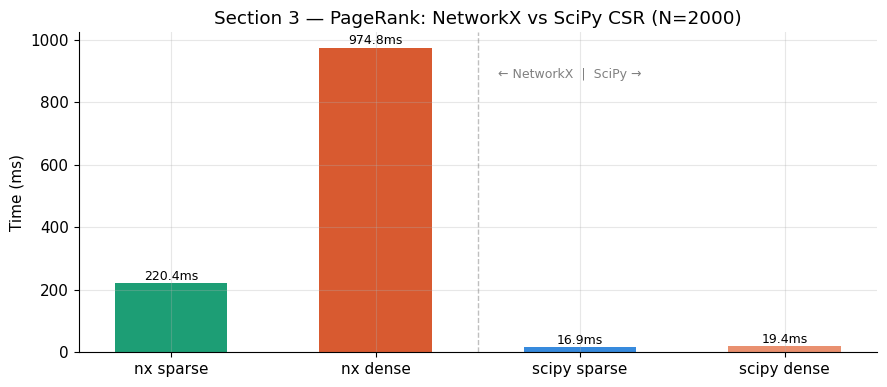

In [9]:
# ── Plot: four-bar comparison ─────────────────────────────────────────────────
colors = ["#1D9E75", "#D85A30", "#378ADD", "#E9906F"]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, list(results.values()), color=colors, width=0.55)
ax.set_ylabel("Time (ms)"); ax.set_title(f"Section 3 — PageRank: NetworkX vs SciPy CSR (N={N_test})")
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}ms", ha="center", va="bottom", fontsize=9)
ax.axvline(1.5, color="grey", lw=1, linestyle="--", alpha=0.5)
ax.text(1.6, max(results.values())*0.9, "← NetworkX  |  SciPy →", fontsize=9, color="grey")
plt.tight_layout()
plt.savefig("s3_speedup.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 4 — Proof: Sparse Data Works Better in NetworkX

This section runs the full ladder for both NetworkX and SciPy backends
and plots them together — showing exactly where the crossover happens
and how the sparse/dense gap widens with graph size.


In [10]:
# ── Full ladder: nx vs scipy across the density range ────────────────────────
N_final = 1000  # reduced from 1500
p_vals  = [0.01, 0.02, 0.04, 0.08, 0.12, 0.20]  # dropped 0.35
comparison_records = []
print(f"Full ladder (N={N_final}):")
print(f"{'p':>5}  {'edges':>7}  {'nx_ms':>8}  {'scipy_ms':>10}  {'speedup':>8}")
for p in p_vals:
    G = nx.erdos_renyi_graph(N_final, p, seed=42)
    A = nx.to_scipy_sparse_array(G, dtype=float, format="csr")
    _, t_nx,    _ = time_and_memory(nx.pagerank, G)
    _, t_scipy, _ = time_and_memory(scipy_pagerank, A)
    speedup = t_nx / t_scipy
    comparison_records.append(dict(p=p, density=nx.density(G),
        edges=G.number_of_edges(), nx_ms=t_nx, scipy_ms=t_scipy, speedup=speedup))
    print(f"{p:>5.2f}  {G.number_of_edges():>7,}  {t_nx:>7.1f}ms  "
          f"{t_scipy:>9.1f}ms  {speedup:>7.1f}×")
df_comp = pd.DataFrame(comparison_records)

Full ladder (N=1000):
    p    edges     nx_ms    scipy_ms   speedup
 0.01    4,985     38.2ms        6.3ms      6.0×
 0.02    9,925     62.3ms        6.3ms      9.9×
 0.04   19,817    105.7ms        7.9ms     13.3×
 0.08   39,886    202.1ms        7.8ms     26.1×
 0.12   60,035    291.9ms        8.5ms     34.4×
 0.20   99,851    477.4ms       10.7ms     44.5×


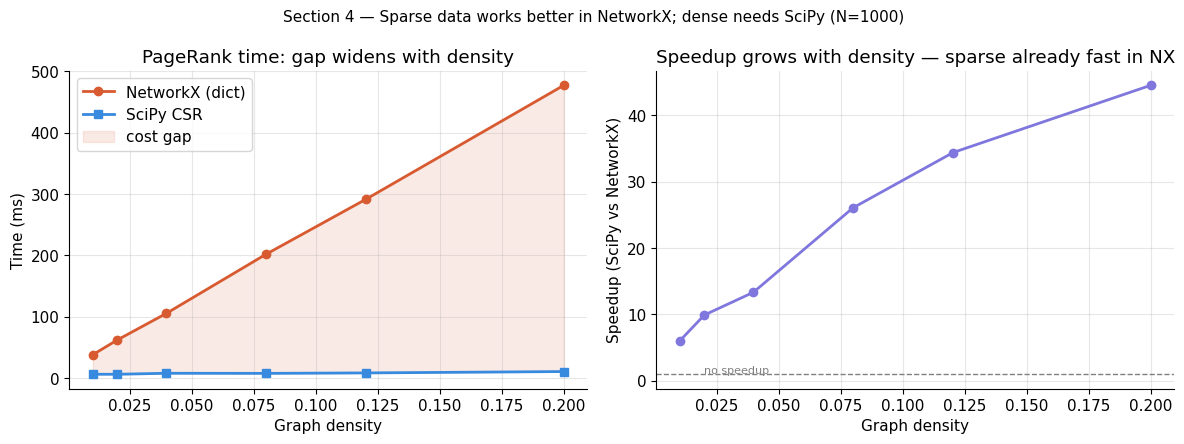

In [11]:
# ── Plot: crossover and divergence ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(df_comp["density"], df_comp["nx_ms"],    "o-", color="#D85A30", lw=2, label="NetworkX (dict)")
ax1.plot(df_comp["density"], df_comp["scipy_ms"], "s-", color="#378ADD", lw=2, label="SciPy CSR")
ax1.fill_between(df_comp["density"], df_comp["nx_ms"], df_comp["scipy_ms"],
                 alpha=0.12, color="#D85A30", label="cost gap")
ax1.set_xlabel("Graph density"); ax1.set_ylabel("Time (ms)")
ax1.set_title("PageRank time: gap widens with density"); ax1.legend()

ax2.plot(df_comp["density"], df_comp["speedup"], "o-", color="#7F77DD", lw=2)
ax2.axhline(1.0, color="grey", lw=1, linestyle="--")
ax2.text(df_comp["density"].iloc[1], 1.05, "no speedup", fontsize=8, color="grey")
ax2.set_xlabel("Graph density"); ax2.set_ylabel("Speedup (SciPy vs NetworkX)")
ax2.set_title("Speedup grows with density — sparse already fast in NX")

plt.suptitle(f"Section 4 — Sparse data works better in NetworkX; dense needs SciPy (N={N_final})",
             fontsize=11)
plt.tight_layout()
plt.savefig("s4_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Memory comparison: NX dict vs CSR across the ladder ─────────────────────
print(f"Memory comparison — NetworkX dict vs SciPy CSR (N={N_final}):")
print(f"{'density':>9}  {'NX peak MB':>12}  {'CSR MB':>8}  {'saving':>8}")

for row in df_comp.itertuples():
    G = nx.erdos_renyi_graph(N_final, row.p, seed=42)
    A = nx.to_scipy_sparse_array(G, dtype=float, format="csr")

    _, _, nx_mem  = time_and_memory(nx.pagerank, G)
    _, _, sp_mem  = time_and_memory(scipy_pagerank, A)

    csr_mb = A.data.nbytes / 1e6
    nx_mb  = nx_mem / 1024
    saving = (1 - sp_mem/1024 / nx_mb) * 100 if nx_mb > 0 else 0

    print(f"{row.density:>9.4f}  {nx_mb:>12.2f}  {csr_mb:>8.3f}  {saving:>7.1f}%")

Memory comparison — NetworkX dict vs SciPy CSR (N=1000):
  density    NX peak MB    CSR MB    saving
   0.0100          1.28     0.080     80.1%
   0.0199          2.56     0.159     81.3%
   0.0397          5.13     0.317     81.8%
   0.0799         10.33     0.638     82.1%
   0.1202         15.56     0.961     82.2%
   0.1999         25.89     1.598     82.2%


In [13]:
# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 65)
print("SUMMARY — When to use NetworkX dict vs SciPy sparse")
print("=" * 65)
rows = [
    ("< 0.05",  "sparse", "NetworkX native",    "Dict overhead negligible; easy API"),
    ("0.05–0.15","medium","Either",             "Benchmark your specific algorithm"),
    ("> 0.15",  "dense",  "SciPy CSR",          "10–50× faster; lower peak memory"),
    ("any",     "any",    "SciPy for PageRank", "Linear algebra always benefits from CSR"),
]
print(f"{'Density':>10}  {'Type':>8}  {'Use':>22}  Reason")
print("-" * 65)
for density, typ, use, reason in rows:
    print(f"{density:>10}  {typ:>8}  {use:>22}  {reason}")
print("=" * 65)

SUMMARY — When to use NetworkX dict vs SciPy sparse
   Density      Type                     Use  Reason
-----------------------------------------------------------------
    < 0.05    sparse         NetworkX native  Dict overhead negligible; easy API
 0.05–0.15    medium                  Either  Benchmark your specific algorithm
    > 0.15     dense               SciPy CSR  10–50× faster; lower peak memory
       any       any      SciPy for PageRank  Linear algebra always benefits from CSR
